In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6,4)

(np.float64(-0.5), np.float64(764.5), np.float64(768.5), np.float64(-0.5))

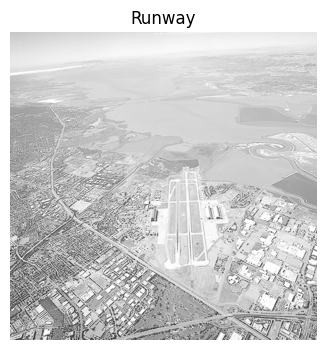

In [4]:
runway = cv2.imread('images/runway.png', 0)
highlights_and_shadows = cv2.imread('images/highlights_and_shadows.jpg')
woman = cv2.imread('images/woman.jpg', 0)
# color_img = cv2.imread('images/gamma.png', 0)

plt.imshow(runway, cmap='gray')
plt.title("Runway")
plt.axis('off')

Question 01

In [5]:
def gamma_correction(image, gamma):
    img = image / 255.0
    result = np.power(img, gamma)
    return (result * 255).astype(np.uint8)

def contrast_stretch(image, r1=0.2, r2=0.8):
    img = image / 255.0
    s = np.zeros_like(img)

    s[img < r1] = 0
    s[(img >= r1) & (img <= r2)] = (img[(img >= r1) & (img <= r2)] - r1) / (r2 - r1)
    s[img > r2] = 1

    return (s * 255).astype(np.uint8)

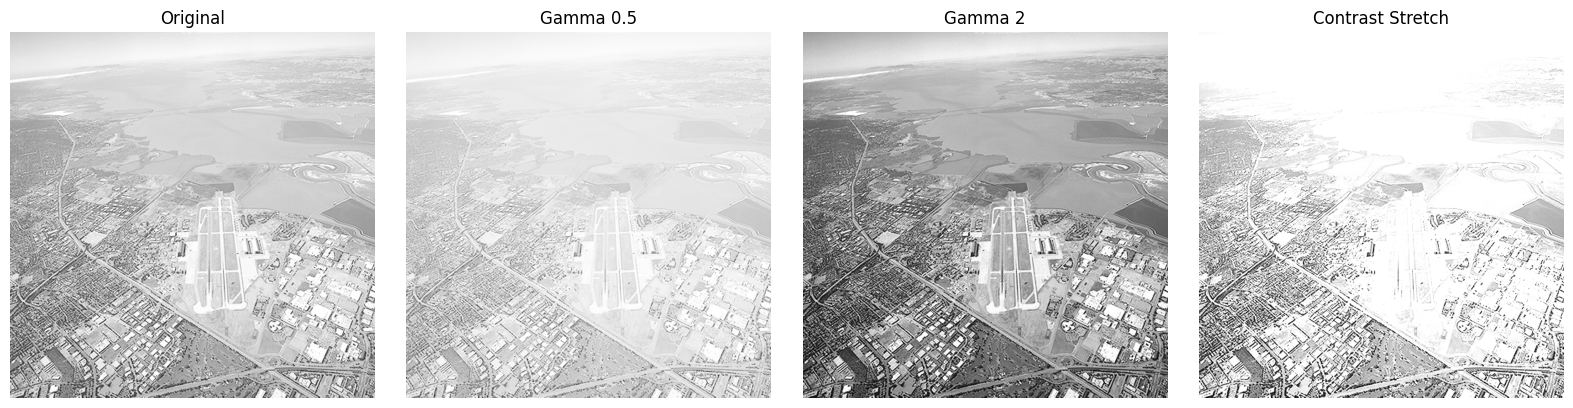

In [26]:
g05 = gamma_correction(runway, 0.5)
g2 = gamma_correction(runway, 2)
cs = contrast_stretch(runway)

titles = ["Original", "Gamma 0.5", "Gamma 2", "Contrast Stretch"]
images = [runway, g05, g2, cs]

plt.figure(figsize=(16, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()

Question 2

(np.float64(-0.5), np.float64(719.5), np.float64(479.5), np.float64(-0.5))

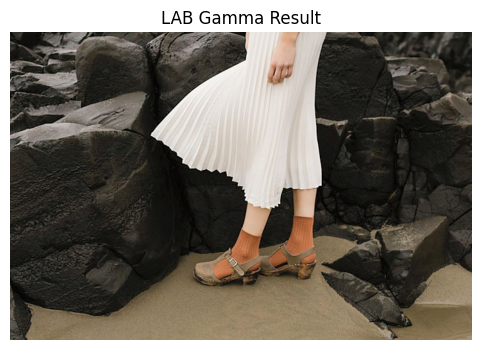

In [7]:
lab = cv2.cvtColor(highlights_and_shadows, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

l_gamma = gamma_correction(l, 0.8)
lab_new = cv2.merge([l_gamma, a, b])
result = cv2.cvtColor(lab_new, cv2.COLOR_LAB2BGR)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("LAB Gamma Result")
plt.axis('off')

Text(0.5, 1.0, 'Histogram Comparison')

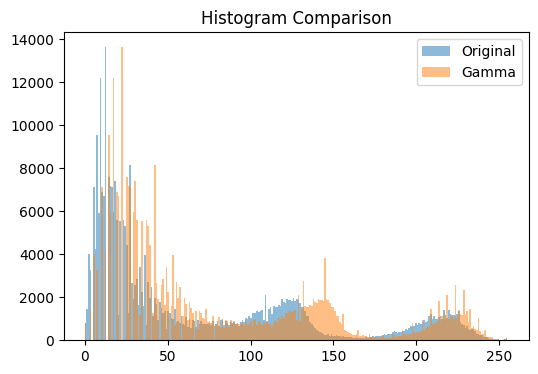

In [8]:
plt.hist(l.flatten(), bins=256, alpha=0.5, label='Original')
plt.hist(l_gamma.flatten(), bins=256, alpha=0.5, label='Gamma')
plt.legend()
plt.title("Histogram Comparison")

Question 3

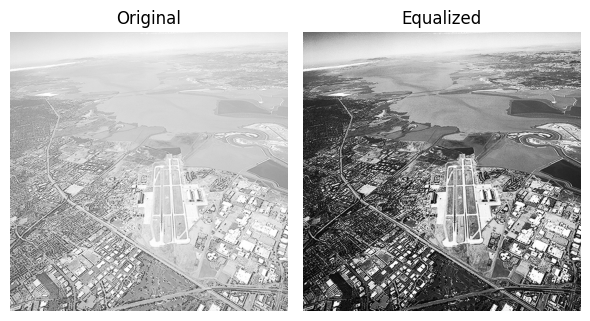

In [9]:
def hist_eq(image):
    hist, bins = np.histogram(image.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf = 255 * cdf / cdf[-1]
    result = np.interp(image.flatten(), bins[:-1], cdf)
    return result.reshape(image.shape).astype(np.uint8)

eq = hist_eq(runway)

plt.subplot(1,2,1)
plt.imshow(runway, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(eq, cmap='gray')
plt.title("Equalized")
plt.axis('off')
plt.tight_layout()

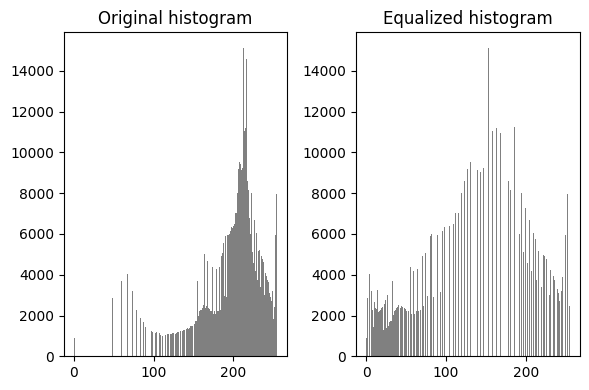

In [10]:
plt.subplot(1,2,1)
plt.hist(runway.flatten(), bins=256, color='gray')
plt.title("Original histogram")

plt.subplot(1,2,2)
plt.hist(eq.flatten(), bins=256, color='gray')
plt.title("Equalized histogram")
plt.tight_layout()

Question 4

Otsu Threshold: 101.0


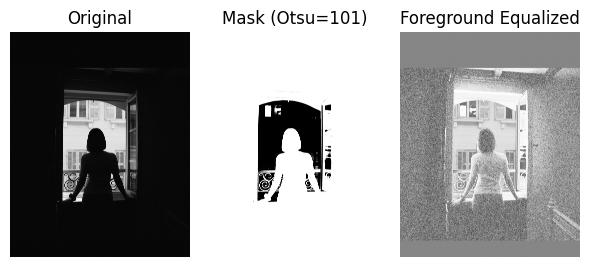

In [29]:
ret, thresh = cv2.threshold(woman, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Otsu Threshold:", ret)

mask = thresh == 0

def hist_eq_masked(image, mask):
    fg = image[mask]
    hist, _ = np.histogram(fg, 256, [0, 256])
    cdf = hist.cumsum()
    cdf = 255 * cdf / cdf[-1]
    out = image.copy()
    out[mask] = np.interp(fg, np.arange(256), cdf).astype(np.uint8)
    return out

result = hist_eq_masked(woman, mask)

plt.subplot(1, 3, 1)
plt.imshow(woman, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title(f"Mask (Otsu={ret:.0f})")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result, cmap='gray')
plt.title("Foreground Equalized")
plt.axis('off')

plt.tight_layout()

Question 5

In [12]:
def gaussian_kernel(size, sigma):
    ax = np.linspace(-(size//2), size//2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    kernel /= np.sum(kernel)
    return kernel

kernel = gaussian_kernel(5, 2)
print(kernel)

[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]


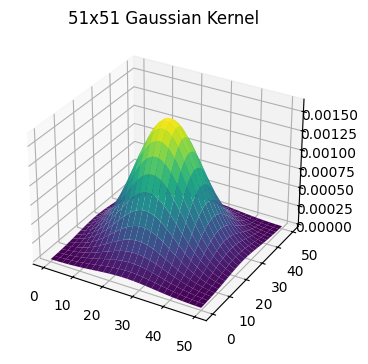

In [13]:
gauss_kernel_51 = gaussian_kernel(51, 10)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x, y = np.meshgrid(np.arange(51), np.arange(51))
ax.plot_surface(x, y, gauss_kernel_51, cmap='viridis')
plt.title("51x51 Gaussian Kernel")
plt.show()

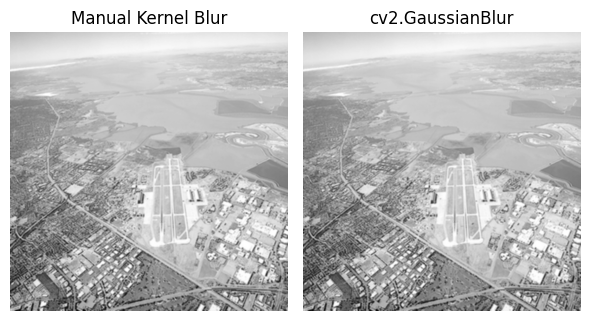

In [14]:
blur_manual = cv2.filter2D(runway, -1, kernel)
blur_cv = cv2.GaussianBlur(runway, (5,5), 2)

plt.subplot(1, 2, 1)
plt.imshow(blur_manual, cmap='gray')
plt.title("Manual Kernel Blur")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blur_cv, cmap='gray')
plt.title("cv2.GaussianBlur")
plt.axis('off')

plt.tight_layout()

Question 6

(a)
G(x,y) = (1/(2πσ²)) exp(−(x²+y²)/(2σ²))
∂G/∂x = G · ∂/∂x[−(x²+y²)/(2σ²)] = G · (−x/σ²) = −(x/σ²)·G(x,y)
Same logic for y → ∂G/∂y = −(y/σ²)·G(x,y) ✓


Text(0.5, 1.0, 'Gradient X')

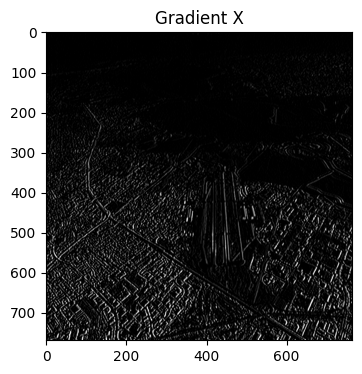

In [15]:
def derivative_gaussian(size=5, sigma=2):
    ax = np.linspace(-(size//2), size//2, size)
    xx, yy = np.meshgrid(ax, ax)

    G = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    Gx = -(xx/sigma**2)*G
    Gy = -(yy/sigma**2)*G

    return Gx, Gy

Gx, Gy = derivative_gaussian()

grad_x = cv2.filter2D(runway, -1, Gx)
grad_y = cv2.filter2D(runway, -1, Gy)

plt.imshow(grad_x, cmap='gray')
plt.title("Gradient X")

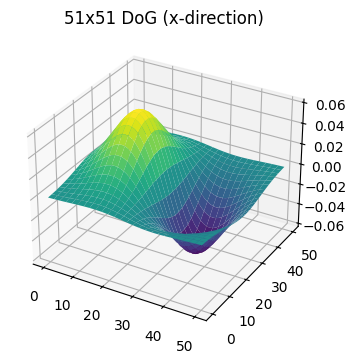

In [16]:
Gx_51, _ = derivative_gaussian(51, 10)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x, y = np.meshgrid(np.arange(51), np.arange(51))
ax.plot_surface(x, y, Gx_51, cmap='viridis')
plt.title("51x51 DoG (x-direction)")
plt.show()


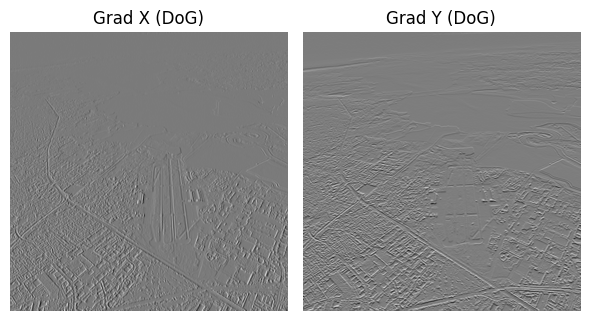

In [17]:
grad_x = cv2.filter2D(runway, cv2.CV_64F, Gx)
grad_y = cv2.filter2D(runway, cv2.CV_64F, Gy)

plt.subplot(1,2,1); plt.imshow(grad_x, cmap='gray'); plt.title("Grad X (DoG)"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(grad_y, cmap='gray'); plt.title("Grad Y (DoG)"); plt.axis('off')
plt.tight_layout()


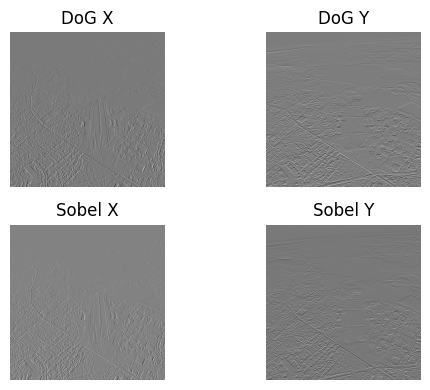

In [18]:
sobel_x = cv2.Sobel(runway, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(runway, cv2.CV_64F, 0, 1, ksize=5)

plt.subplot(2,2,1); plt.imshow(grad_x, cmap='gray'); plt.title("DoG X"); plt.axis('off')
plt.subplot(2,2,2); plt.imshow(grad_y, cmap='gray'); plt.title("DoG Y"); plt.axis('off')
plt.subplot(2,2,3); plt.imshow(sobel_x, cmap='gray'); plt.title("Sobel X"); plt.axis('off')
plt.subplot(2,2,4); plt.imshow(sobel_y, cmap='gray'); plt.title("Sobel Y"); plt.axis('off')
plt.tight_layout()


Question 7

In [19]:
def nearest(img, scale):
    h, w = img.shape
    new = np.zeros((int(h*scale), int(w*scale)), dtype=img.dtype)

    for i in range(new.shape[0]):
        for j in range(new.shape[1]):
            new[i,j] = img[int(i/scale), int(j/scale)]
    return new

In [20]:
def bilinear(img, scale):
    h, w = img.shape
    new_h, new_w = int(h*scale), int(w*scale)
    out = np.zeros((new_h, new_w), dtype=np.float64)

    for i in range(new_h):
        for j in range(new_w):
            x, y = i / scale, j / scale
            x0, y0 = int(np.floor(x)), int(np.floor(y))
            x1, y1 = min(x0 + 1, h - 1), min(y0 + 1, w - 1)
            a, b = x - x0, y - y0
            out[i, j] = ((1-a)*(1-b)*img[x0,y0] + (1-a)*b*img[x0,y1]
                         + a*(1-b)*img[x1,y0] + a*b*img[x1,y1])
    return out.astype(img.dtype)


In [21]:
def ssd(a, b):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    return np.sum((a - b)**2) / a.size


In [22]:
small = cv2.imread('images/im01small.png', 0)
large = cv2.imread('images/im01.png', 0)
scale = large.shape[0] / small.shape[0]

up_nn = nearest(small, scale)
up_bl = bilinear(small, scale)

# crop or pad to exactly match large.shape (rounding may give ±1)
up_nn = up_nn[:large.shape[0], :large.shape[1]]
up_bl = up_bl[:large.shape[0], :large.shape[1]]

print("Nearest SSD:", ssd(up_nn, large))
print("Bilinear SSD:", ssd(up_bl, large))


Nearest SSD: 137.2095703125
Bilinear SSD: 201.4493962191358


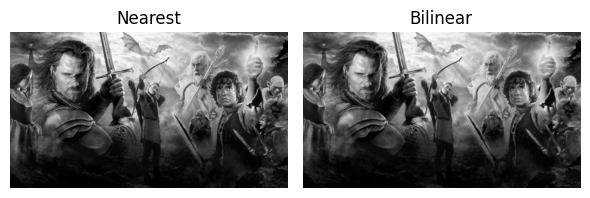

In [23]:
plt.subplot(1,2,1)
plt.imshow(up_nn, cmap='gray')
plt.title("Nearest")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(up_bl, cmap='gray')
plt.title("Bilinear")
plt.axis('off')

plt.tight_layout()

Question 8

In [24]:
noise = cv2.imread('images/noise.png', 0)

[ WARN:0@15.901] global loadsave.cpp:278 findDecoder imread_('images/noise.png'): can't open/read file: check file path/integrity


In [25]:
gauss = cv2.GaussianBlur(noise, (5,5), 2)
median = cv2.medianBlur(noise, 5)

plt.subplot(1,3,1)
plt.imshow(noise, cmap='gray')
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gauss, cmap='gray')
plt.title("Gaussian")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(median, cmap='gray')
plt.title("Median")
plt.axis('off')

plt.tight_layout()


error: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/smooth.dispatch.cpp:618: error: (-215:Assertion failed) !_src.empty() in function 'GaussianBlur'


Question 9

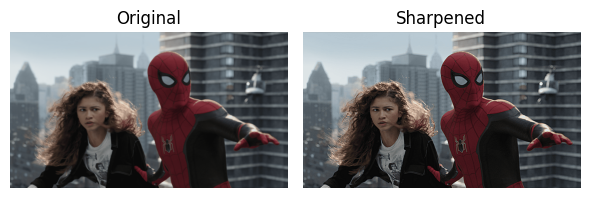

In [ ]:
spider = cv2.imread('images/spider.png')
kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharp = cv2.filter2D(spider, -1, kernel) 

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(spider, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(sharp, cv2.COLOR_BGR2RGB))
plt.title("Sharpened")
plt.axis('off')

plt.tight_layout()


Question 10

Text(0.5, 1.0, 'Bilateral Filter')

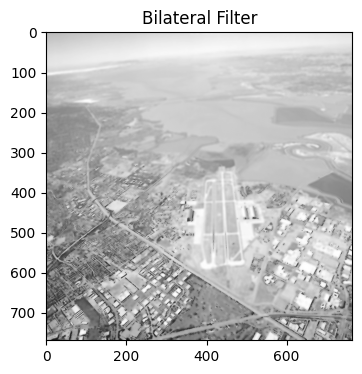

In [ ]:
bilateral = cv2.bilateralFilter(runway, 9, 75, 75)

plt.imshow(bilateral, cmap='gray')
plt.title("Bilateral Filter")

In [ ]:
def bilateral_filter(img, d, sigma_s, sigma_r):
    img = img.astype(np.float64)
    h, w = img.shape
    radius = d // 2
    out = np.zeros_like(img)

    # spatial (domain) Gaussian — precomputed once
    ax = np.arange(-radius, radius + 1)
    xx, yy = np.meshgrid(ax, ax)
    spatial = np.exp(-(xx**2 + yy**2) / (2 * sigma_s**2))

    padded = np.pad(img, radius, mode='reflect')

    for i in range(h):
        for j in range(w):
            patch = padded[i:i+d, j:j+d]
            # range (intensity) Gaussian
            range_w = np.exp(-((patch - img[i, j])**2) / (2 * sigma_r**2))
            weights = spatial * range_w
            out[i, j] = np.sum(patch * weights) / np.sum(weights)

    return out.astype(np.uint8)


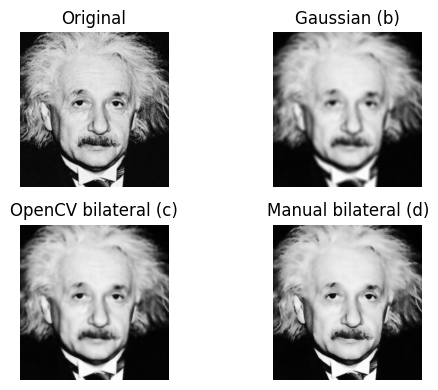

In [ ]:
einstein = cv2.imread('images/einstein.png', 0)
gauss = cv2.GaussianBlur(einstein, (9, 9), 5)
bilateral_cv = cv2.bilateralFilter(einstein, 9, 75, 75)
bilateral_my = bilateral_filter(einstein, 9, sigma_s=5, sigma_r=30)

plt.subplot(2,2,1)
plt.imshow(einstein, cmap='gray');
plt.title("Original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(gauss, cmap='gray')
plt.title("Gaussian (b)")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(bilateral_cv, cmap='gray')
plt.title("OpenCV bilateral (c)")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(bilateral_my, cmap='gray')
plt.title("Manual bilateral (d)")  
plt.axis('off')

plt.tight_layout()

Question 11

Question 12

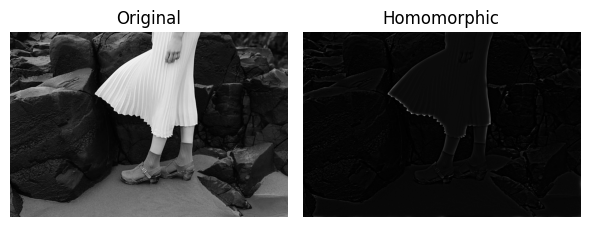

In [ ]:
img = cv2.imread('images/highlights_and_shadows.jpg', 0).astype(np.float64)

eps = 1.0
L = np.log(img + eps)

F = np.fft.fftshift(np.fft.fft2(L))

rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
u = np.arange(rows).reshape(-1, 1) - crow
v = np.arange(cols).reshape(1, -1) - ccol
D2 = u**2 + v**2

gammaL, gammaH, c, D0 = 0.4, 1.8, 1.0, 30
H = (gammaH - gammaL) * (1 - np.exp(-c * D2 / (D0**2))) + gammaL

G = H * F
Lp = np.real(np.fft.ifft2(np.fft.ifftshift(G)))

out = np.exp(Lp) - eps
out = cv2.normalize(out, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(out, cmap='gray'); plt.title("Homomorphic"); plt.axis('off')
plt.tight_layout()
